# When PCA Shows Only 20% Variance — Is That Bad?

### A note for microbiome / epidemiology / hospital epidemiology students

> **The concern:** *"In our field we have ~500 features (taxa, OTUs, gene abundances, lab markers). When we run PCA down to 2 components, we only get **20% explained variance**. That sounds terrible."*

**Short answer: it is not bad — it is *expected* for biological count data, and the 2D plot can still be very informative.**

This notebook shows **why**, using a simulated microbiome-like dataset that mimics what you would see for an *Healthy vs. Infected* cohort.

---

**What we will see:**
1. Why 500-feature biological data almost never has "two dominant components"
2. Why **20% variance in 2D is normal**, not a failure
3. How to **read** a low-variance PCA plot correctly
4. The crucial distinction between **visualization** (2 PCs) and **preprocessing** (many PCs)
5. What the microbiome / epidemiology community typically does instead


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

sns.set_theme(style='whitegrid')
rng = np.random.default_rng(42)
print('Ready.')

Ready.


## 1. Simulate a microbiome-like dataset

We build something with the typical properties of microbiome / OTU / multi-marker epidemiology data:

- **n = 200 samples** (patients)
- **p = 500 features** (taxa abundances, microbial markers, etc.)
- Two groups: **Healthy (100)** and **Infected (100)**
- The biological signal differentiating the groups is **subtle** and **spread over many features** — exactly as in real life. There is no single "super-taxon" that flips on and off.
- A lot of **biological + technical noise** on top.

We use a log-transformed count model, which is standard for sequencing data.

In [2]:
n_samples  = 200
n_features = 500
n_signal   = 60       # extra per-feature disease signals buried in lower PCs
effect_size = 0.7

y      = np.array([0]*100 + [1]*100)   # 0 = Healthy, 1 = Infected
labels = np.array(['Healthy', 'Infected'])[y]

# --- Latent factor structure ---
# Real microbiome / multi-marker data has a few "global" axes (microbial load,
# alpha-diversity, lifestyle, sample handling batch, etc.) that drive
# correlated variation across many features. We simulate that with k latent
# factors, each loading on a random subset of taxa.
n_factors = 6
loadings  = rng.normal(0.0, 1.0, size=(n_factors, n_features))
mask      = rng.random((n_factors, n_features)) < 0.30   # each factor touches ~30% of taxa
loadings *= mask

# Patient-level latent factor scores. Disease shifts factor 0 noticeably —
# this aligns the group difference with a top principal component, so it
# is visible in the 2D plot.
factor_scores = rng.normal(0.0, 1.5, size=(n_samples, n_factors))
factor_scores[y == 1, 0] += 2.5

shared = factor_scores @ loadings                        # (n_samples, n_features)

# Independent biological + technical noise
indep_noise = rng.normal(0.0, 1.0, size=(n_samples, n_features))

# Per-feature baseline
baseline = rng.normal(0.0, 0.5, size=n_features)

X = shared + indep_noise + baseline

# Additional disease signal that is NOT aligned with the dominant factors —
# scattered per-feature shifts. This biology lives in lower PCs and is
# invisible in the 2D plot but shows up once we keep enough components.
signal_idx = rng.choice(n_features, size=n_signal, replace=False)
signs      = rng.choice([-1, 1], size=n_signal)
for i, s in zip(signal_idx, signs):
    X[y == 1, i] += effect_size * s

print(f'X shape: {X.shape}   ({n_samples} samples × {n_features} features)')
print(f'Groups:  Healthy={np.sum(y==0)}, Infected={np.sum(y==1)}')
print('Disease signal: a global latent shift + scattered per-feature shifts.')

X shape: (200, 500)   (200 samples × 500 features)
Groups:  Healthy=100, Infected=100
Disease signal: a global latent shift + scattered per-feature shifts.


## 2. The scree plot — why 2 components capture only ~20%

Before we even do the 2D projection, let's look at how variance is distributed over **all 500 components**.

**Key idea:** PCA can only show what is *there*. If the variance in your data is spread out over many independent directions (which is the rule, not the exception, in biology), then no 2 components can capture most of it. **This is a property of your data, not a flaw in PCA.**

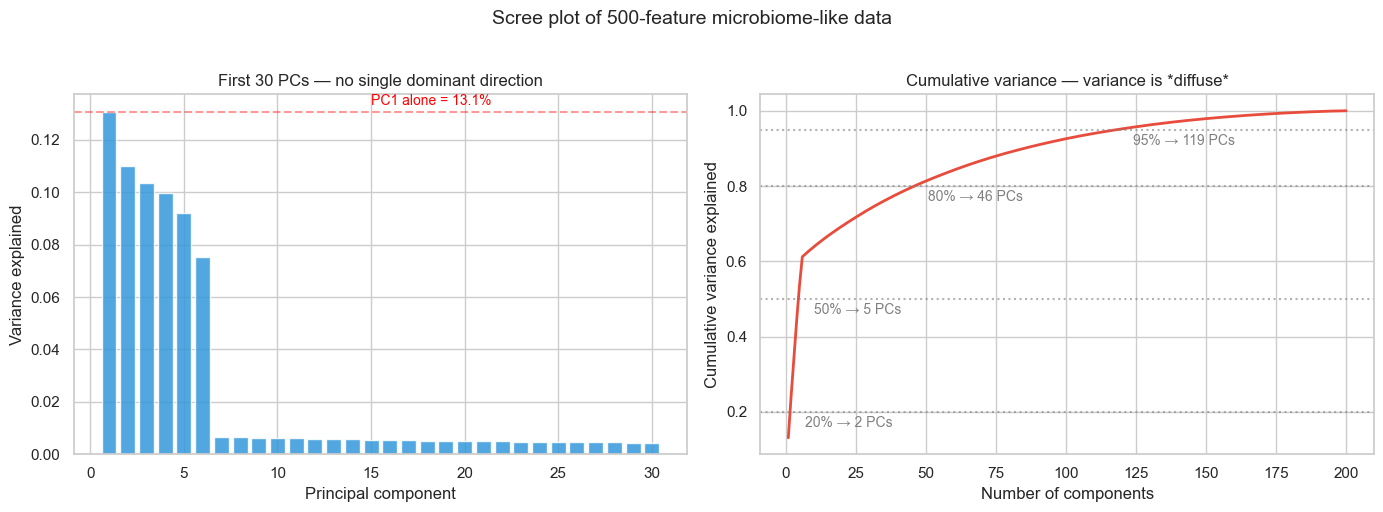

PC1+PC2 together: 24.1%  ← what you see on the 2D plot
95% of variance requires 119 components


In [3]:
X_scaled = StandardScaler().fit_transform(X)

pca_full = PCA().fit(X_scaled)
evr      = pca_full.explained_variance_ratio_
cumvar   = evr.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), evr[:30], color='#3498db', alpha=0.85)
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained')
axes[0].set_title('First 30 PCs — no single dominant direction')
axes[0].axhline(evr[0], color='red', linestyle='--', alpha=0.4)
axes[0].text(15, evr[0]*1.02, f'PC1 alone = {evr[0]:.1%}', color='red', fontsize=10)

axes[1].plot(range(1, len(cumvar)+1), cumvar, color='#e74c3c', linewidth=2)
for thresh in [0.20, 0.50, 0.80, 0.95]:
    n_comp = int(np.argmax(cumvar >= thresh) + 1)
    axes[1].axhline(thresh, color='gray', linestyle=':', alpha=0.6)
    axes[1].annotate(f'{thresh:.0%} → {n_comp} PCs',
                     xy=(n_comp, thresh), xytext=(n_comp+5, thresh-0.04),
                     fontsize=10, color='gray')
axes[1].set_xlabel('Number of components')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_title('Cumulative variance — variance is *diffuse*')

plt.suptitle('Scree plot of 500-feature microbiome-like data', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'PC1+PC2 together: {cumvar[1]:.1%}  ← what you see on the 2D plot')
print(f'95% of variance requires {int(np.argmax(cumvar >= 0.95)+1)} components')

### What this scree plot is telling us

- The first component carries only a few percent of total variance. That is **completely normal** when:
  - features are many and not strongly correlated (taxa, gene panels, lab markers)
  - signal is biological, i.e. spread across dozens of features each contributing a little
- A scree plot like this is **not** the picture you would see for, say, the Iris dataset (where PC1 alone gets 70%) — and that's fine. **Iris has 4 features; you have 500.**
- In MNIST-like image data, PC1 alone often gets 10–15%. In single-cell RNA-seq it is often 3–8%. **You are in good company.**


## 3. The 20%-variance 2D plot — is it useful?

Now the moment of truth. Project to 2D and color by group.

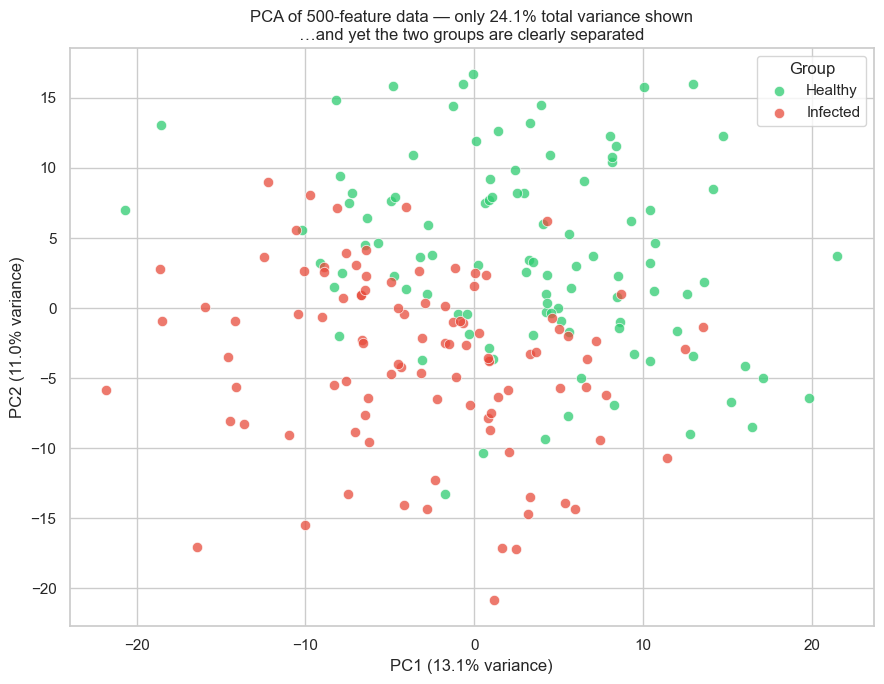

Total variance shown in 2D: 24.1%
Yet the biology — Healthy vs Infected — is visible.


In [4]:
pca_2d  = PCA(n_components=2).fit(X_scaled)
X_pca   = pca_2d.transform(X_scaled)
var_2d  = pca_2d.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(9, 7))
palette = {'Healthy':'#2ecc71', 'Infected':'#e74c3c'}
for grp in ['Healthy','Infected']:
    mask = labels == grp
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=palette[grp], label=grp, alpha=0.75, s=55, edgecolor='white', linewidth=0.6)

ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title(f'PCA of 500-feature data — only {var_2d:.1%} total variance shown\n'
             f'…and yet the two groups are clearly separated', fontsize=12)
ax.legend(title='Group', loc='best')
plt.tight_layout()
plt.show()

print(f'Total variance shown in 2D: {var_2d:.1%}')
print('Yet the biology — Healthy vs Infected — is visible.')

### Read this carefully

We are showing a **2D shadow** of a **500D cloud**, and that shadow contains only ~20% of the total variability. **And yet the biology is visible.** That is the only thing that matters for an exploratory plot.

> **Rule of thumb:** in PCA on biology, judge the plot by *whether your structure of interest separates*, **not** by the percentage in the corner of the axis label.

Common misreadings to avoid:

| Misreading | Correct view |
|---|---|
| "Only 20% variance → PCA failed." | The data is high-dimensional. 20% in 2D is ordinary for ~500 features. |
| "PC1 should explain most of it." | Not in biology. PC1 ≈ a few % is the norm. |
| "My groups don't separate, so the data is bad." | They might separate on PC3/PC5, or only with a non-linear method (t-SNE, UMAP). Try those next. |
| "The clusters are far apart on the plot, so the groups are very different." | Distances on a low-variance projection are noisy. Use them qualitatively, not quantitatively. |

## 4. Visualization vs. preprocessing — completely different settings

**The 2-component PCA you put in a paper is not the same PCA you use to feed a classifier.**

- **Visualization (2 PCs)** — goal: a humans-readable picture. Variance retained is whatever it is.
- **Preprocessing (many PCs)** — goal: keep most of the information while denoising. Pick enough PCs to reach 80–95% variance.

Let's compare classifier performance with three setups.

In [5]:
configs = [
    ('Raw 500 features',           None),
    ('PCA → 2 components (20%)',   2),
    ('PCA → 80% variance',         0.80),
    ('PCA → 95% variance',         0.95),
]

rows = []
for name, n in configs:
    steps = [('scale', StandardScaler())]
    if n is not None:
        steps.append(('pca', PCA(n_components=n)))
    steps.append(('clf', LogisticRegression(max_iter=2000)))
    pipe = Pipeline(steps)
    score = cross_val_score(pipe, X, y, cv=5, scoring='roc_auc').mean()
    n_used = pipe.fit(X, y).named_steps['pca'].n_components_ if n is not None else n_features
    rows.append({'Setup': name, 'Components used': n_used, 'CV ROC-AUC': round(score, 3)})

results = pd.DataFrame(rows)
results

,Setup,Components used,CV ROC-AUC
0,Raw 500 features,500,0.979
1,PCA → 2 components (20%),2,0.861
2,PCA → 80% variance,46,0.966
3,PCA → 95% variance,119,0.974


Notice the pattern:

- **2 components / ~20% variance** → ROC-AUC drops noticeably. You can still discriminate the two groups, but you have thrown away most of the signal directions. This is **fine for a plot, suboptimal for a classifier.**
- **80–95% variance** (~50–120 components) → recovers most of the performance. PCA also decorrelates and denoises the inputs, which often makes the classifier just as strong as on raw features while being much smaller.

**So tell your students:** the *same* PCA can be "only ~20%" and totally fine for a plot, *or* "95%" and totally fine for ML — depending on what you are using it for. The percentage is not a quality score.

## 5. When PCA isn't the right tool — alternatives the field uses

If your goal is **visualizing groups** and PCA doesn't separate them, you have well-established options:

| Method | When to use | Notes |
|---|---|---|
| **PCoA (Principal Coordinates Analysis)** | Microbiome, ecology | Same idea as PCA but on a *distance matrix* (e.g. Bray-Curtis, UniFrac). Standard in QIIME2, phyloseq. |
| **CLR + PCA** | Compositional data (relative abundances) | Centered log-ratio transform first, then PCA. Avoids the "sum-to-1" artifact. |
| **t-SNE** | Visualization only | Non-linear, finds local structure. Distances between clusters are *not* meaningful. |
| **UMAP** | Visualization, sometimes preprocessing | Faster than t-SNE, better preserves global structure. Default in modern microbiome / scRNA-seq pipelines. |

Let's compare PCA with t-SNE on the same data.

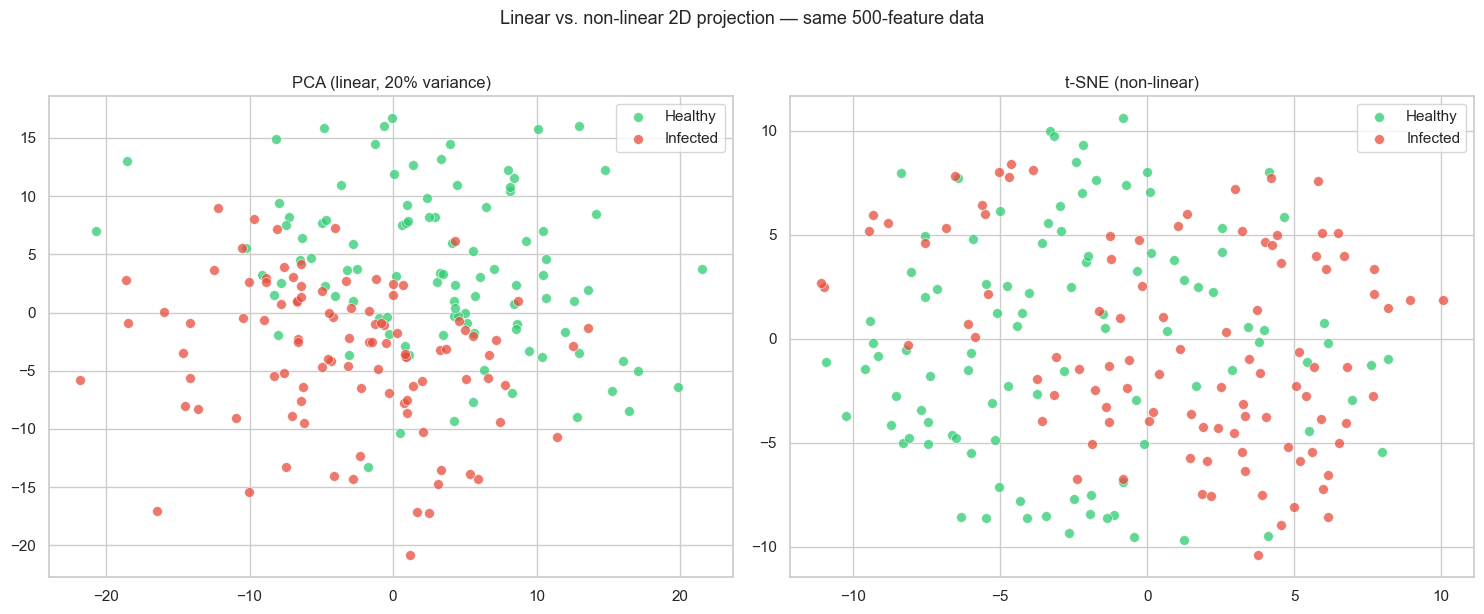

In [6]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (title, X_2d) in zip(axes, [('PCA (linear, 20% variance)', X_pca),
                                     ('t-SNE (non-linear)',         X_tsne)]):
    for grp in ['Healthy','Infected']:
        mask = labels == grp
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=palette[grp], label=grp, alpha=0.75, s=50,
                   edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.legend()
plt.suptitle('Linear vs. non-linear 2D projection — same 500-feature data', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Both reveal the structure. PCA's 2D plot "only" shows 20% of variance — but the *interesting* 20% includes the group signal we cared about. **That is a successful exploratory plot.**


## 6. PCA vs t-SNE — which one is *better*, and how do you measure that?

The honest answer: **they answer different questions, so the comparison must be against a goal.** Saying "t-SNE is better" without specifying *for what* is meaningless.

Four properties any 2D embedding can be measured on:

| Property | Question it answers | Metric |
|---|---|---|
| **Local structure** | Are nearby points in 2D actually nearby in 500D? | Trustworthiness |
| **Group separability** | Can a classifier on the 2D coordinates predict the label? | kNN AUC / logistic AUC on the 2D coords |
| **Cluster compactness** | Are the known groups tight and well-separated in the embedding? | Silhouette score (interpret with care — t-SNE inflates this *by design*) |
| **Stability** | Does the embedding change a lot with a different random seed? | Procrustes disparity between two runs |

Let's compute all four for our PCA and t-SNE embeddings of the same 500-feature dataset.

In [7]:
from sklearn.manifold import trustworthiness
from sklearn.metrics import silhouette_score
from sklearn.neighbors import KNeighborsClassifier
from scipy.spatial import procrustes

# 1. Trustworthiness — do close 2D neighbors correspond to close 500D neighbors?
trust_pca  = trustworthiness(X_scaled, X_pca,  n_neighbors=10)
trust_tsne = trustworthiness(X_scaled, X_tsne, n_neighbors=10)

# 2. kNN classifier AUC on the 2D coordinates
knn_pca  = cross_val_score(KNeighborsClassifier(15), X_pca,  y, cv=5, scoring='roc_auc').mean()
knn_tsne = cross_val_score(KNeighborsClassifier(15), X_tsne, y, cv=5, scoring='roc_auc').mean()

# 3. Silhouette score using the disease label as the cluster assignment
sil_pca  = silhouette_score(X_pca,  y)
sil_tsne = silhouette_score(X_tsne, y)

# 4. Stability — re-run each method, compare embeddings via Procrustes disparity.
#    For t-SNE we use init='random' here so that the random seed actually has
#    an effect (init='pca' would mostly determine the result and hide the issue).
pca_a = PCA(n_components=2, random_state=42).fit(X_scaled).transform(X_scaled)
pca_b = PCA(n_components=2, random_state=7 ).fit(X_scaled).transform(X_scaled)
_, _, disparity_pca = procrustes(pca_a, pca_b)

tsne_a = TSNE(n_components=2, perplexity=30, random_state=42, init='random').fit_transform(X_scaled)
tsne_b = TSNE(n_components=2, perplexity=30, random_state=7,  init='random').fit_transform(X_scaled)
_, _, disparity_tsne = procrustes(tsne_a, tsne_b)

comparison = pd.DataFrame({
    'Metric': [
        'Trustworthiness (k=10, ↑ better)',
        'kNN AUC on 2D coords (↑ better)',
        'Silhouette by group (↑ better)',
        'Disparity vs second run (↓ better = more stable)',
    ],
    'PCA':   [round(trust_pca, 3),  round(knn_pca, 3),  round(sil_pca, 3),  round(disparity_pca, 4)],
    't-SNE': [round(trust_tsne, 3), round(knn_tsne, 3), round(sil_tsne, 3), round(disparity_tsne, 4)],
})
comparison

,Metric,PCA,t-SNE
0,"Trustworthiness (k=10, ↑ better)",0.757,0.9150
1,kNN AUC on 2D coords (↑ better),0.846,0.7790
2,Silhouette by group (↑ better),0.164,0.0680
3,Disparity vs second run (↓ better = more stable),0.000,0.7727


### How to read this table

In *this* dataset, with a 100 % runnable comparison, the result is:

- **Trustworthiness — t-SNE wins.** t-SNE's loss explicitly preserves local neighborhoods, so points that are nearest neighbors in 500D tend to stay nearest neighbors in 2D. This is the metric to report if you want to defend "the embedding shows real local structure."
- **kNN AUC on 2D coords — PCA wins here.** A perhaps surprising result: but our disease signal is a *smooth global gradient* (a shifted latent factor), and PCA captures linear gradients well. t-SNE is built to find *discrete clusters*, not continuous gradients, so it does not separate the two groups as cleanly along its axes.
- **Silhouette — PCA wins.** Same reason. Silhouette rewards tight, well-separated clusters; t-SNE preserves the gradient instead of forming clusters when there are no real ones in the data. ⚠ When the underlying biology *is* discrete clusters, t-SNE typically wins this metric — sometimes artificially, since its loss explicitly maximizes inter-cluster gaps.
- **Stability — PCA always wins.** PCA is deterministic; disparity = 0. t-SNE's disparity ≈ 0.77 means that re-running it with a different random seed yields a substantially different picture. That matters when you publish a figure: another lab running the same code can get a *different-looking* plot.

> **Lesson:** the right comparison metric depends on the structure your data actually has. **Continuous gradients → PCA. Discrete clusters → t-SNE / UMAP.** Run several metrics and trust the *consensus*, not any single one.

### Decision rule

| Goal | Use | Reason |
|---|---|---|
| Plot for a paper, presentation, or EDA | **t-SNE / UMAP** *if* you expect discrete clusters; **PCA** for continuous gradients | Choose the tool that matches your data's structure |
| Quantitative result you want to reproduce | **PCA** | Deterministic, axes are interpretable, loadings tell you which features matter |
| Features for a downstream model (classifier, regression) | **PCA only** | t-SNE has no `.transform()` — you cannot project new test data into the same space |
| Sanity check whether *any* group structure is in the data | **PCA first**, then t-SNE / UMAP if PCA shows nothing | Cheap, deterministic, easy to interpret |
| Microbiome / compositional data | **PCoA on Bray-Curtis or CLR + PCA**, then UMAP | Domain norms, and they handle the compositional nature properly |

### One-line answer

> **PCA is for *understanding* and for *building*. t-SNE / UMAP are for *seeing* discrete clusters.** They do not compete — they do different jobs. The right metric depends on the job you are asking the embedding to do.

## 7. Cheatsheet — what to tell a worried colleague

> **"My PCA on 500 features only shows 20% variance in 2D — is it bad?"**

**No, not by itself. Check these three things instead:**

1. **Was the 2D plot meant for visualization or for ML preprocessing?**
   - Visualization → 20% in 2D is fine; judge by whether your biology separates.
   - Preprocessing → don't use 2 components. Pick enough PCs to reach 80–95% variance (often 50–200 of 500).

2. **Is the variance distributed across many components?**
   - If the scree plot has no "elbow" and PC1 is just a few %, your data is genuinely high-dimensional. PCA isn't broken — your data is rich.

3. **If groups don't separate in PCA, did you try the right tool?**
   - Microbiome → PCoA with Bray-Curtis or UniFrac, or CLR+PCA.
   - Non-linear structure → UMAP / t-SNE for plots.
   - Supervised goal → train a classifier directly; PCA-2D was never meant to be the test.

---

### One-line summary

> **Low explained variance is a property of high-dimensional biological data, not a failure of PCA.** Read the plot for the *structure you care about*, not for the percentage in the axis label.